In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

In [1]:
!py -3.14 -m pip install numpy pandas matplotlib scikit-learn torch

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
torch.manual_seed(42)

In [4]:
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
w = np.random.randn(30) * 0.01
b = np.random.randn() * 0.01

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def forward(x, w, b):
    return sigmoid(np.dot(x, w) + b)

X_test_first_5 = X_test_scaled[:5]
predicted_probs = forward(X_test_first_5, w, b)

print("Predicted probabilities for the first 5 test rows:")
for i, prob in enumerate(predicted_probs):
    print(f"Row {i+1}: {prob:.4f}")

Predicted probabilities for the first 5 test rows:
Row 1: 0.4962
Row 2: 0.5175
Row 3: 0.5071
Row 4: 0.4874
Row 5: 0.4839


model implemented logical regression

In [6]:
class NumpyMLP:
    def __init__(self):
        np.random.seed(42)
        self.W1 = np.random.randn(30, 8) * np.sqrt(2.0 / 30)
        self.b1 = np.zeros(8)
        
        self.W2 = np.random.randn(8, 1) * np.sqrt(2.0 / 8)
        self.b2 = np.zeros(1)

    def forward(self, X):
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = np.maximum(0, self.Z1)

        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = 1 / (1 + np.exp(-self.Z2))
        
        return self.A2

numpy_model = NumpyMLP()
numpy_preds = numpy_model.forward(X_test_scaled)

print(f"Output shape: {numpy_preds.shape}")
print("First 5 predictions:\n", numpy_preds[:5].flatten())

Output shape: (114, 1)
First 5 predictions:
 [0.45299955 0.46601069 0.56604814 0.40817775 0.36364703]


guiding question answer:
because of matrix multiplication. N x 30 * 30 x 8 * 8 x 1 demands N x 1 structure

In [8]:
class TorchMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(30, 8)
        self.fc2 = nn.Linear(8, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x

torch_model = TorchMLP()

with torch.no_grad():
    torch_model.fc1.weight.data = torch.from_numpy(numpy_model.W1.T).float()
    torch_model.fc1.bias.data = torch.from_numpy(numpy_model.b1).float()
    torch_model.fc2.weight.data = torch.from_numpy(numpy_model.W2.T).float()
    torch_model.fc2.bias.data = torch.from_numpy(numpy_model.b2).float()

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
with torch.no_grad():
    torch_preds = torch_model(X_test_tensor).numpy()

max_diff = np.max(np.abs(numpy_preds - torch_preds))
print(f"Maximum absolute difference: {max_diff:.8e}")

Maximum absolute difference: 6.35925064e-08


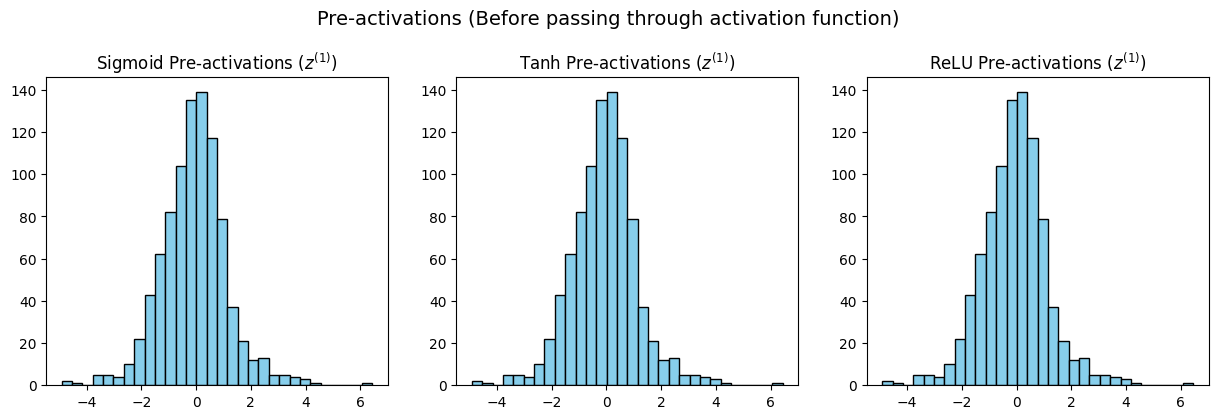

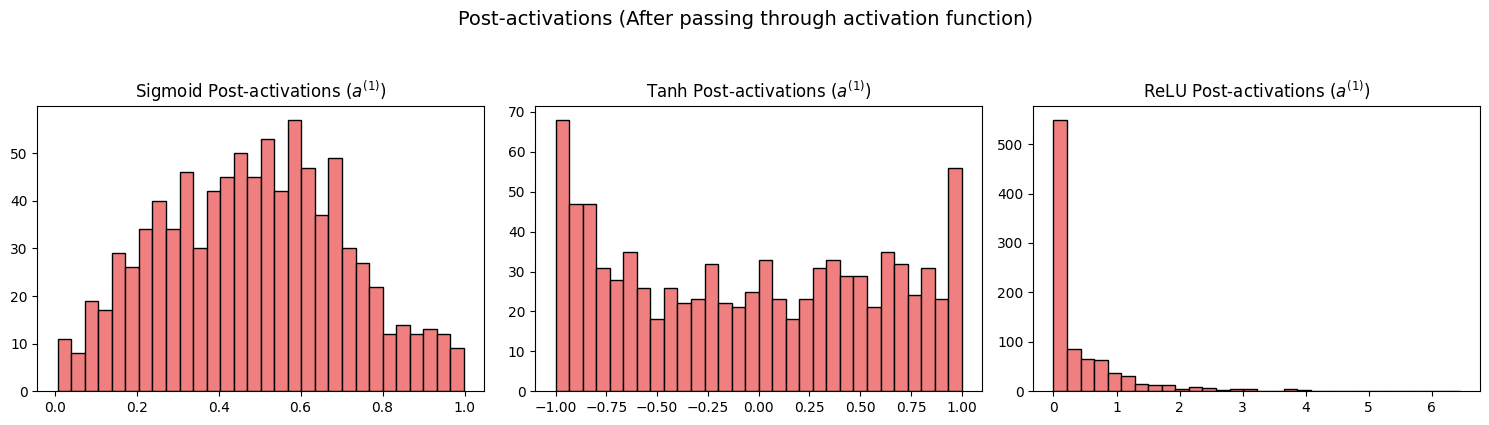

In [9]:
class ActivationExperiment(nn.Module):
    def __init__(self, act_fn):
        super().__init__()
        self.fc1 = nn.Linear(30, 8)
        self.fc2 = nn.Linear(8, 1)
        self.act_fn = act_fn
        
        # Copy identical weights for a perfectly fair comparison
        with torch.no_grad():
            self.fc1.weight.data = torch.from_numpy(numpy_model.W1.T).float()
            self.fc1.bias.data = torch.from_numpy(numpy_model.b1).float()
            self.fc2.weight.data = torch.from_numpy(numpy_model.W2.T).float()
            self.fc2.bias.data = torch.from_numpy(numpy_model.b2).float()

    def forward(self, x):
        z1 = self.fc1(x)
        a1 = self.act_fn(z1)
        out = torch.sigmoid(self.fc2(a1))
        return z1, a1, out

# Define variants
models = {
    'Sigmoid': ActivationExperiment(torch.sigmoid),
    'Tanh': ActivationExperiment(torch.tanh),
    'ReLU': ActivationExperiment(torch.relu)
}

# Run forward passes and collect data
results = {}
with torch.no_grad():
    for name, model in models.items():
        z1, a1, _ = model(X_test_tensor)
        results[name] = {'z1': z1.numpy().flatten(), 'a1': a1.numpy().flatten()}

# Plotting
fig_z, axes_z = plt.subplots(1, 3, figsize=(15, 4))
fig_a, axes_a = plt.subplots(1, 3, figsize=(15, 4))

for i, (name, data) in enumerate(results.items()):
    # Pre-activations
    axes_z[i].hist(data['z1'], bins=30, color='skyblue', edgecolor='black')
    axes_z[i].set_title(f'{name} Pre-activations ($z^{{(1)}}$)')
    
    # Post-activations
    axes_a[i].hist(data['a1'], bins=30, color='lightcoral', edgecolor='black')
    axes_a[i].set_title(f'{name} Post-activations ($a^{{(1)}}$)')

fig_z.suptitle("Pre-activations (Before passing through activation function)", fontsize=14, y=1.05)
fig_a.suptitle("Post-activations (After passing through activation function)", fontsize=14, y=1.05)

plt.tight_layout()
plt.show()

Sigmoid & Tanh: Sigmoid has very few values stuck at the extreme edges (0 and 1). Tanh has a large portion of its values slammed against the edges (-1 and 1).

ReLU: About half (~50%) of the outputs are exactly zero (turned off).

Why ReLU is a better default: Sigmoid and Tanh flatten out high and low numbers, which causes the network to get "stuck" and stop learning. ReLU doesn't flatten positive numbers, so learning stays fast. Also, turning half the units off (the giant spike at zero) makes the network simpler and faster to run.